# 11 — Outliers con IQR estratificado
Regla de Tukey dentro de cada estrato materia × ámbito: un valor es outlier leve si supera
Q3 + 1,5·IQR y severo si supera Q3 + 3·IQR. **No se elimina ninguna fila**: se agregan banderas,
versiones winsorizadas (tope en el percentil 95 del estrato) y log(1 + x) de los volúmenes.

In [1]:
%run -i modulos/comun.ipynb
%run -i modulos/outliers.ipynb
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

OUT_FEATURES = CURATED / "features"
OUT_EDA = CURATED / "eda"
OUT_FIG = REPORTS / "figures"

df = pd.read_parquet(OUT_FEATURES / "dataset_analitico_indicadores.parquet")
df_curado, umbrales = aplicar_transformaciones_curadas(df)
print(len(df.columns), "->", len(df_curado.columns), "columnas; filas:", len(df_curado))
assert len(df_curado) == 1997

df_curado.to_parquet(OUT_FEATURES / "dataset_analitico_curado.parquet", index=False)
df_curado.to_csv(OUT_FEATURES / "dataset_analitico_curado.csv", index=False, encoding="utf-8")
umbrales.to_csv(OUT_EDA / "resumen_outliers_estratificado.csv", index=False, encoding="utf-8")
umbrales.head(10)

100 -> 115 columnas; filas: 1997


,n,q1,mediana,q3,iqr,limite_inf,limite_sup,limite_severo,p95,estrato,columna,n_outliers,n_severos
0,40,0.75,37.5,113.00,112.25,0.0,281.375,449.75,1597.85,Partido Administrativo Coactivo Fiscal y Tribu...,atendidas,8,8
1,120,1.00,40.5,361.00,360.00,0.0,901.000,1441.00,2065.30,Partido de Trabajo y Seguridad Social __ capital,atendidas,13,9
2,108,0.00,1.0,20.25,20.25,0.0,50.625,81.00,427.85,Partido de Trabajo y Seguridad Social __ provi...,atendidas,19,16
3,250,4.00,24.5,165.50,161.50,0.0,407.750,650.00,2144.60,Público Civil y Comercial __ capital,atendidas,43,33
4,225,0.00,9.0,69.00,69.00,0.0,172.500,276.00,1109.60,Público Civil y Comercial __ provincia,atendidas,38,30
5,250,0.00,6.0,36.75,36.75,0.0,91.875,147.00,190.55,Público Niñez y Adolescencia __ capital,atendidas,28,18
6,225,0.00,3.0,14.00,14.00,0.0,35.000,56.00,90.80,Público Niñez y Adolescencia __ provincia,atendidas,34,24
7,230,2.00,28.0,170.50,168.50,0.0,423.250,676.00,1537.70,Público de Familia __ capital,atendidas,30,22
8,207,1.00,8.0,80.50,79.50,0.0,199.750,319.00,1236.50,Público de Familia __ provincia,atendidas,31,24
9,40,0.00,12.0,53.75,53.75,0.0,134.375,215.00,191.60,Partido Administrativo Coactivo Fiscal y Tribu...,nuevas_ingresadas,5,2


## Cuántos outliers hay

In [2]:
proc = df_curado[df_curado["tipo_elemento_analitico"] == "proceso"]
filas = []
for nombre in ["carga", "ingresos", "congestion", "duracion"]:
    leve = int(proc["es_outlier_" + nombre + "_iqr"].sum())
    severo = int(proc["es_outlier_severo_" + nombre + "_iqr"].sum())
    filas.append({"variable": nombre, "leves": leve, "severos": severo, "pct_leves": round(leve / len(proc) * 100, 1)})
conteo = pd.DataFrame(filas)
conteo

,variable,leves,severos,pct_leves
0,carga,244,184,14.7
1,ingresos,246,170,14.9
2,congestion,97,53,5.9
3,duracion,96,53,5.8


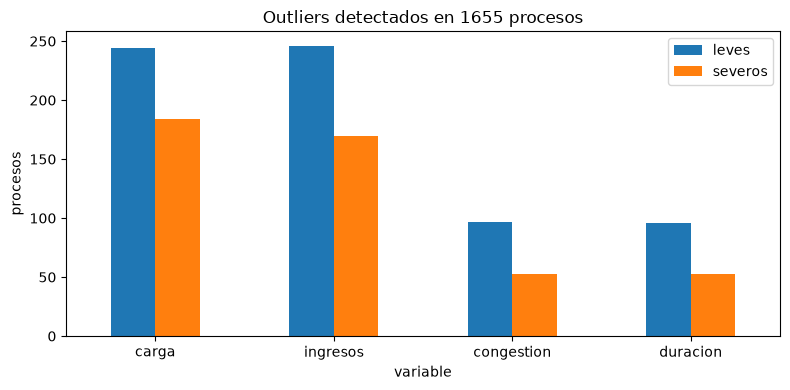

In [3]:
conteo.set_index("variable")[["leves", "severos"]].plot(kind="bar", figsize=(8, 4), rot=0)
plt.title("Outliers detectados en " + str(len(proc)) + " procesos")
plt.ylabel("procesos")
plt.tight_layout()
plt.show()

## Las transformaciones no cambian el orden (Spearman = 1 si el orden se conserva)

In [4]:
rho_log = spearmanr(proc["atendidas"], proc["log_atendidas"])[0]
con_tc = proc[proc["tasa_congestion"].notnull()]
rho_win = spearmanr(con_tc["tasa_congestion"], con_tc["tasa_congestion_winsorizada"])[0]
print("atendidas vs log_atendidas:", round(rho_log, 4))
print("tasa_congestion vs winsorizada:", round(rho_win, 4))

atendidas vs log_atendidas: 1.0
tasa_congestion vs winsorizada: 0.9994


## Figura del reporte: antes y después

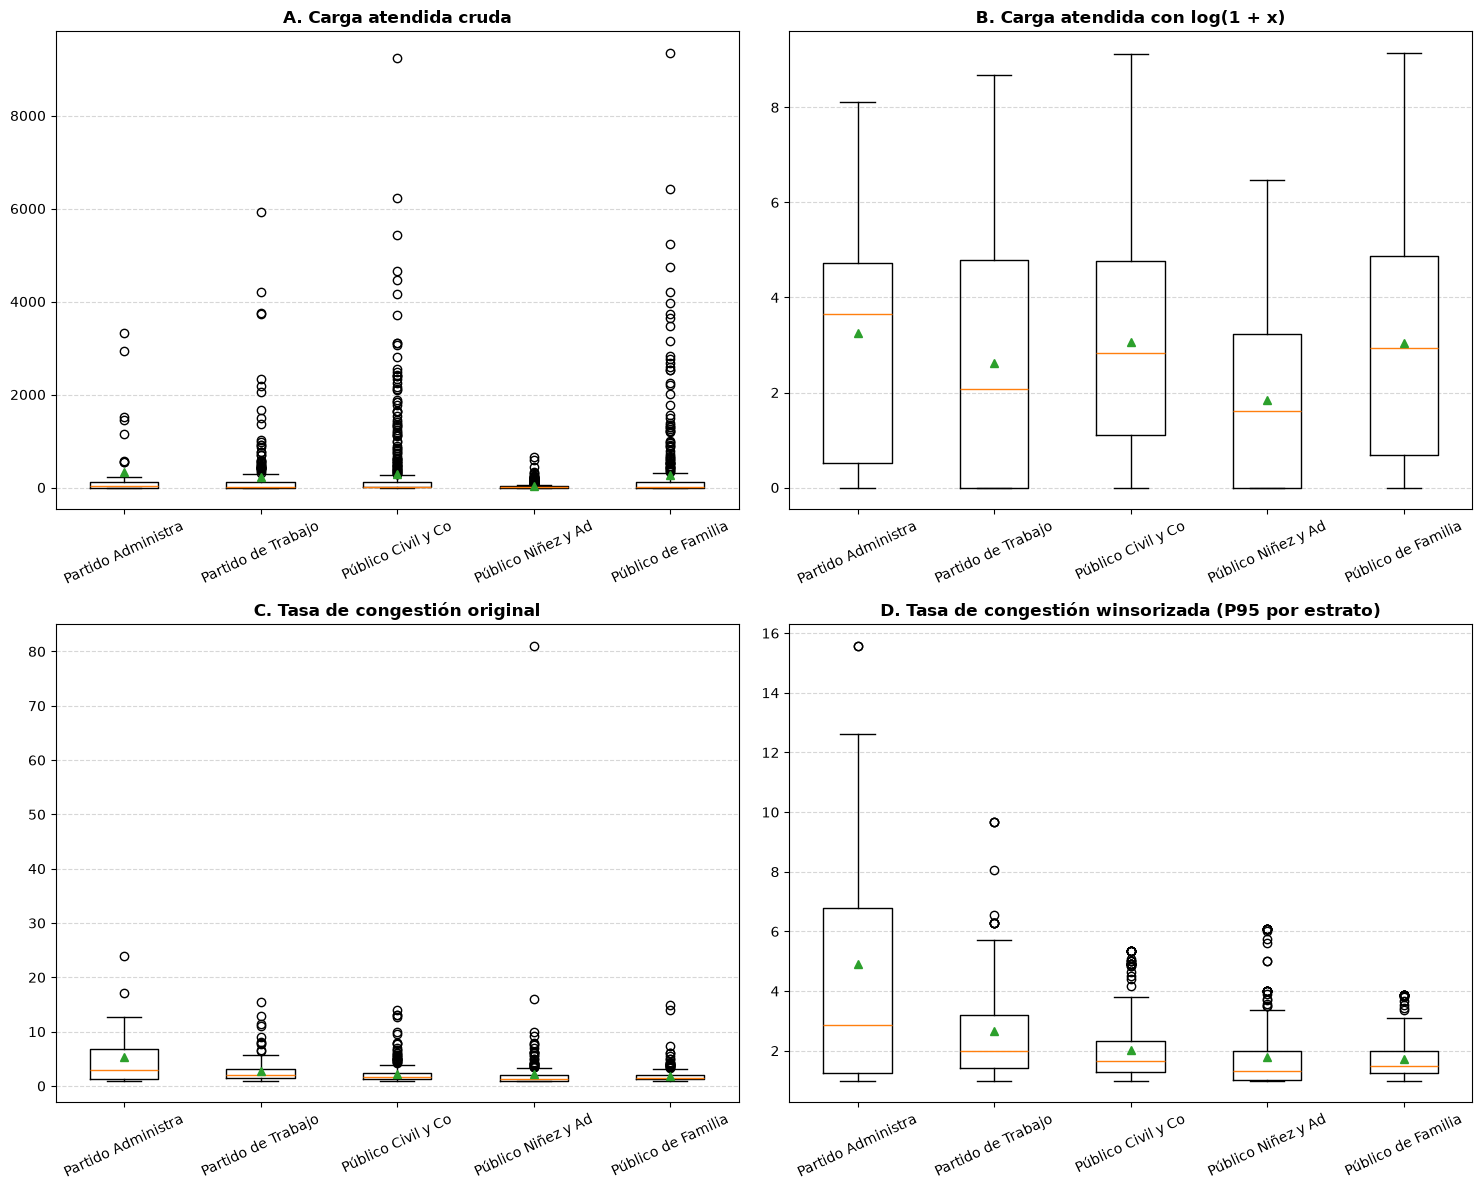

In [5]:
materias = sorted(proc["materia_homologada"].unique())
etiquetas = [m[:18] for m in materias]
paneles = [
    (proc, "atendidas", "A. Carga atendida cruda"),
    (proc, "log_atendidas", "B. Carga atendida con log(1 + x)"),
    (con_tc, "tasa_congestion", "C. Tasa de congestión original"),
    (con_tc, "tasa_congestion_winsorizada", "D. Tasa de congestión winsorizada (P95 por estrato)"),
]
fig, ejes = plt.subplots(2, 2, figsize=(15, 12))
for k in range(4):
    datos, columna, titulo = paneles[k]
    eje = ejes[k // 2][k % 2]
    series = []
    for m in materias:
        series.append(datos[datos["materia_homologada"] == m][columna].values)
    eje.boxplot(series, tick_labels=etiquetas, showmeans=True)
    eje.set_title(titulo, fontweight="bold")
    eje.tick_params(axis="x", rotation=25)
    eje.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_FIG / "02_boxplots_outliers_iqr.png", dpi=200)
plt.show()